In [1]:
# Import necssary libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/

# Dataset Load

In [2]:
# Providing dataset path
base_dir = r"C:\Users\user\Documents\Python Code\German_Traffic_Sign_deep_Learning\GTSRB_Data"

train_dir = os.path.join(base_dir, "Train")
test_csv = os.path.join(base_dir, "Test.csv")

In [3]:
# Setting Class Names 
classes = {
    0:'Speed limit (20km/h)', 1:'Speed limit (30km/h)',
    2:'Speed limit (50km/h)', 3:'Speed limit (60km/h)',
    4:'Speed limit (70km/h)', 5:'Speed limit (80km/h)',
    6:'End of speed limit (80km/h)', 7:'Speed limit (100km/h)',
    8:'Speed limit (120km/h)', 9:'No passing',
    10:'No passing veh over 3.5 tons', 11:'Right-of-way at intersection',
    12:'Priority road', 13:'Yield', 14:'Stop',
    15:'No vehicles', 16:'Veh > 3.5 tons prohibited',
    17:'No entry', 18:'General caution',
    19:'Dangerous curve left', 20:'Dangerous curve right',
    21:'Double curve', 22:'Bumpy road', 23:'Slippery road',
    24:'Road narrows on the right', 25:'Road work',
    26:'Traffic signals', 27:'Pedestrians',
    28:'Children crossing', 29:'Bicycles crossing',
    30:'Beware of ice/snow', 31:'Wild animals crossing',
    32:'End speed + passing limits', 33:'Turn right ahead',
    34:'Turn left ahead', 35:'Ahead only',
    36:'Go straight or right', 37:'Go straight or left',
    38:'Keep right', 39:'Keep left',
    40:'Roundabout mandatory', 41:'End of no passing',
    42:'End no passing veh > 3.5 tons'
}

In [4]:
# Setting Image sizes and Batch sizes
IMG_SIZE = (50, 50)
BATCH_SIZE = 32
NUM_CLASSES = 43

In [5]:
# Dataset Split for training and validation 
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=[str(i) for i in range(43)],
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=[str(i) for i in range(43)],
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 39209 files belonging to 43 classes.
Using 31368 files for training.
Found 39209 files belonging to 43 classes.
Using 7841 files for validation.


In [6]:
# Loading test dataset
test_df = pd.read_csv(test_csv)

print(test_df.info())
print(test_df.head())
print(test_df.columns)

test_paths = [
    os.path.join(base_dir, path.replace("/", os.sep))
    for path in test_df["Path"].values
]

test_labels = test_df["ClassId"].values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12630 entries, 0 to 12629
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    12630 non-null  int64 
 1   Height   12630 non-null  int64 
 2   Roi.X1   12630 non-null  int64 
 3   Roi.Y1   12630 non-null  int64 
 4   Roi.X2   12630 non-null  int64 
 5   Roi.Y2   12630 non-null  int64 
 6   ClassId  12630 non-null  int64 
 7   Path     12630 non-null  object
dtypes: int64(7), object(1)
memory usage: 789.5+ KB
None
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png
Index(['Width', 'Heig

In [7]:
def load_test_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(load_test_image)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [8]:
# normalizing the data
normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# Visualizing Sample Images

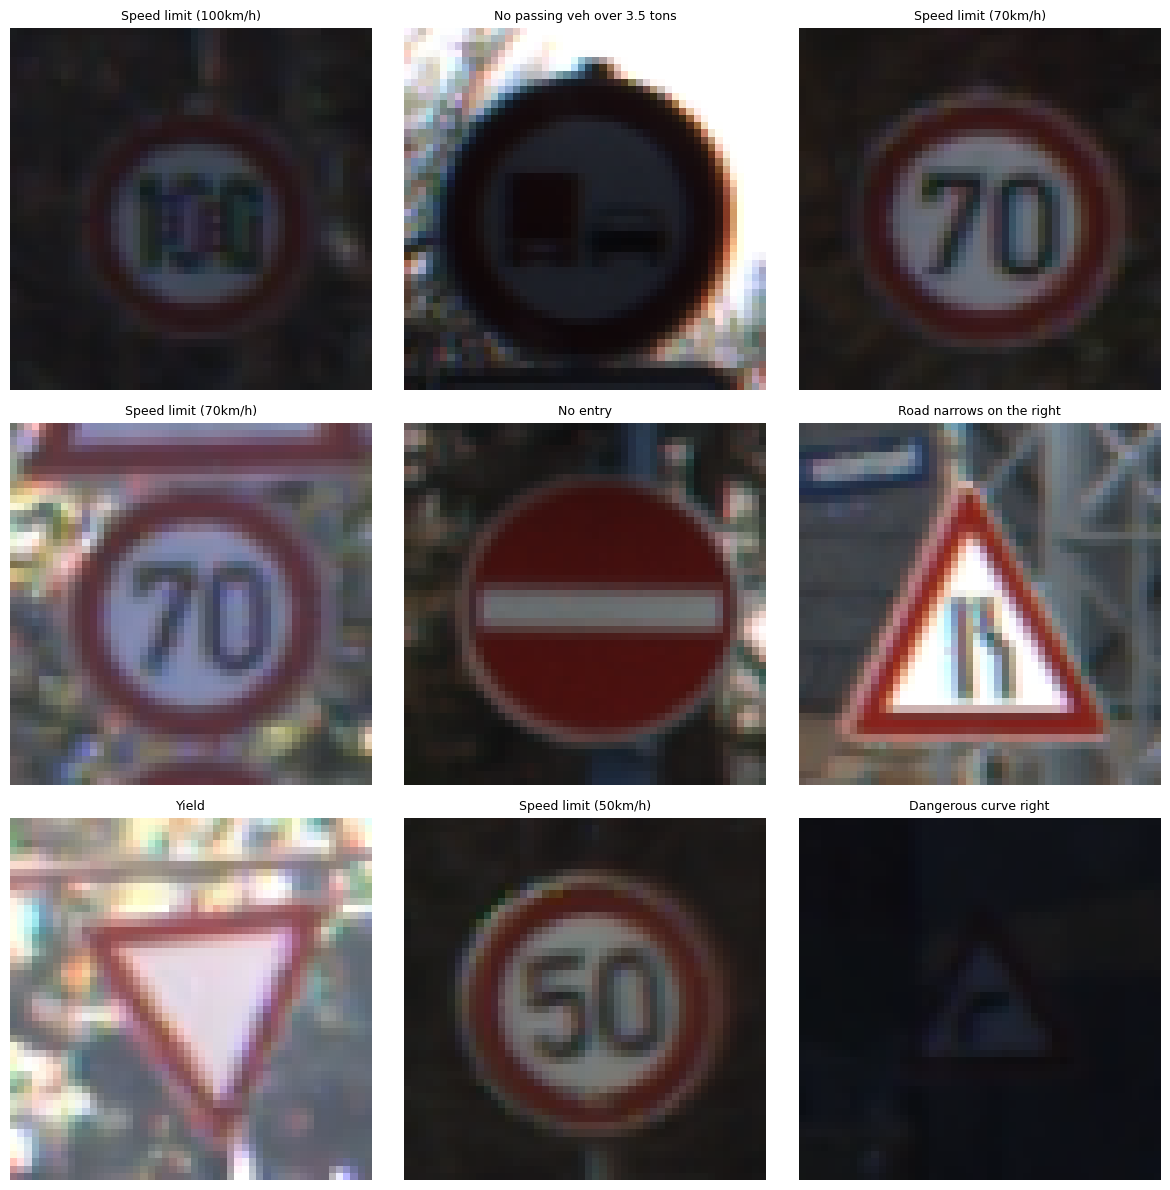

In [9]:
# Plotting sample images
plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):
    for i in range(9):
        label_id = int(labels[i].numpy())

        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(classes[label_id], fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

# CNN Model

In [10]:
# create CNN Model
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(50, 50, 3)),

    tf.keras.layers.Conv2D(16, 5, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Conv2D(32, 5, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Conv2D(128, 3, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(43, activation="softmax")
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 46, 46, 16)          │           1,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 46, 46, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 46, 46, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 42, 42, 32)          │          12,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 42, 42, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 42, 42, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 21, 21, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 19, 19, 64)          │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 19, 19, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 19, 19, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 17, 17, 128)         │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 17, 17, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,194,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │              

 Total params: 4,325,531 (16.50 MB)

 Trainable params: 4,324,027 (16.49 MB)

 Non-trainable params: 1,504 (5.88 KB)

In [11]:
# Train CNN Model
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 97s 96ms/step - accuracy: 0.9363 - loss: 0.2494 - val_accuracy: 0.9878 - val_loss: 0.0425
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 94s 96ms/step - accuracy: 0.9932 - loss: 0.0267 - val_accuracy: 0.9911 - val_loss: 0.0316
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 93s 94ms/step - accuracy: 0.9934 - loss: 0.0228 - val_accuracy: 0.9881 - val_loss: 0.0527
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 94s 96ms/step - accuracy: 0.9955 - loss: 0.0159 - val_accuracy: 0.9948 - val_loss: 0.0179
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 96s 98ms/step - accuracy: 0.9963 - loss: 0.0137 - val_accuracy: 0.9931 - val_loss: 0.0245
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 96s 98ms/step - accuracy: 0.9967 - loss: 0.0110 - val_accuracy: 0.9926 - val_loss: 0.0240
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 93s 94ms/step - accuracy: 0.9968 - loss: 0.0104 - val_accuracy: 0.9901 - val_loss: 0.0374
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 90s 92ms/step - accuracy: 0.9958 - loss: 0.0148 - 

In [12]:
# Evaluate Model
test_loss, test_acc = cnn_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

395/395 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9760 - loss: 0.1093
Test Loss: 0.10930535942316055
Test Accuracy: 0.9760094881057739


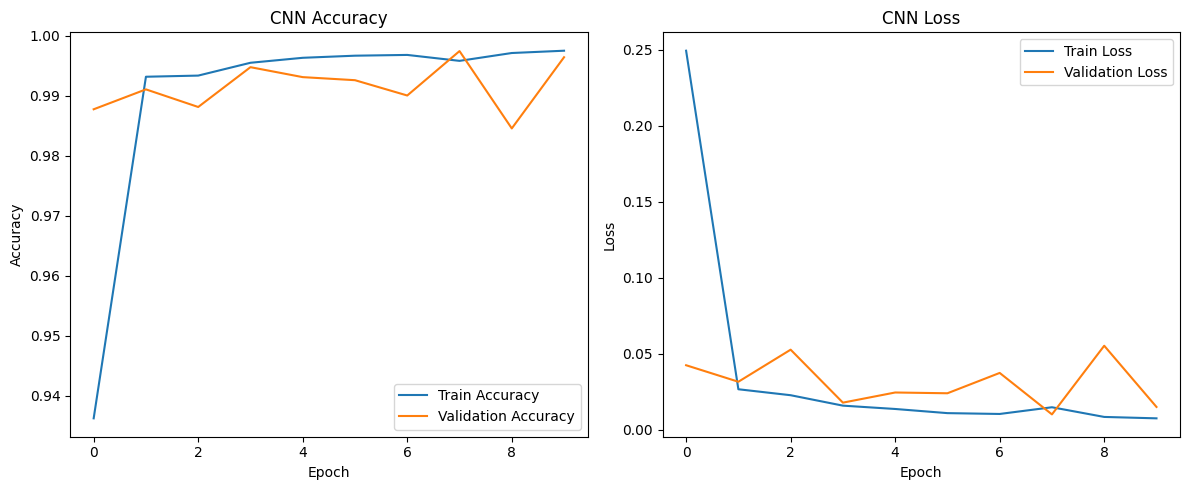

In [13]:
# Evaluation chart: accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

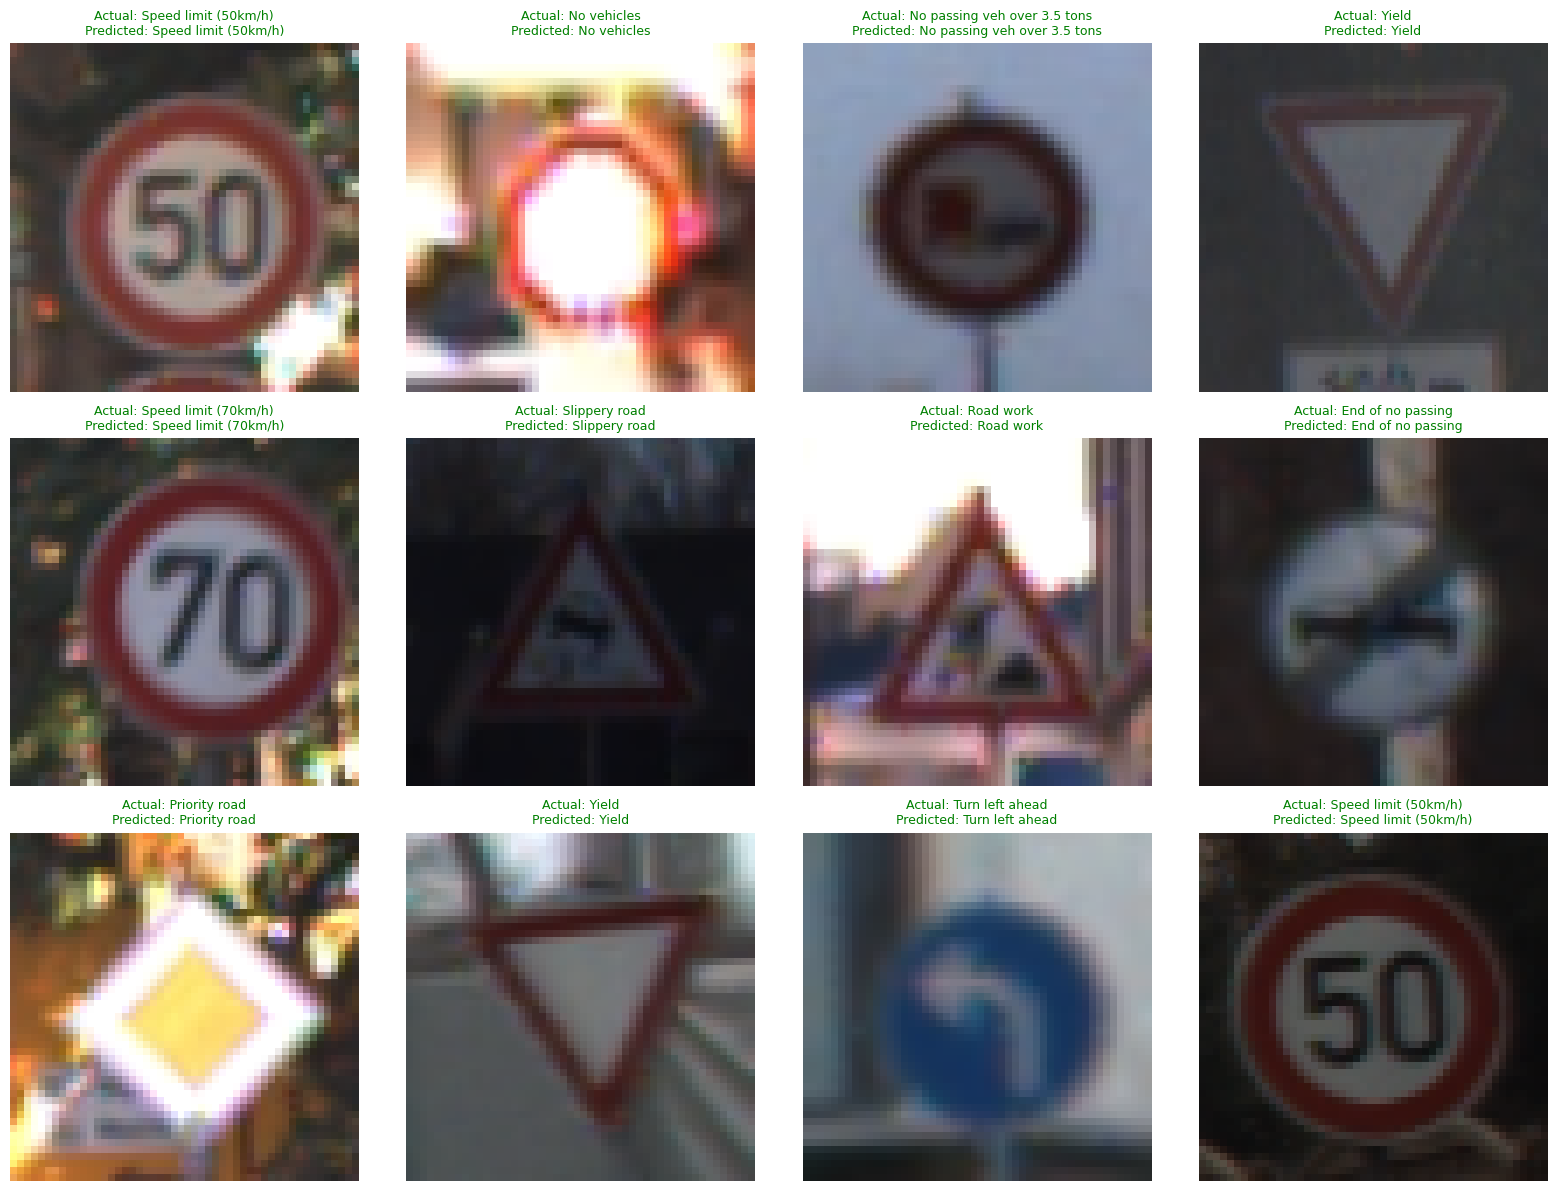

In [14]:
# Prediction visualisation with actual and predicted class names
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
X_test = []

for path in test_paths:
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    X_test.append(image.numpy())

X_test = np.array(X_test)
fig, ax = plt.subplots(3, 4)
fig.set_size_inches(16, 12)

for i in range(3):
    for j in range(4):
        idx = np.random.randint(0, len(X_test))

        actual = int(y_true[idx])
        predicted = int(y_pred[idx])

        ax[i, j].imshow(X_test[idx])

        if actual == predicted:
            color = "green"
        else:
            color = "red"

        ax[i, j].set_title(
            "Actual: " + classes[actual] +
            "\nPredicted: " + classes[predicted],
            color=color,
            fontsize=9
        )
        ax[i, j].axis("off")

plt.tight_layout()
plt.show()

# MobileNetV2 model

In [15]:
# Create MobileNetV2 model
num_classes = len(classes)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(50, 50, 3),   
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

transfer_model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

C:\Users\user\AppData\Local\Temp\ipykernel_24972\2579228996.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 2, 2, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 43)                  │           5,547 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,427,499 (9.26 MB)

 Trainable params: 169,515 (662.17 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
# Train Model
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 50s 47ms/step - accuracy: 0.4419 - loss: 1.8822 - val_accuracy: 0.6520 - val_loss: 1.1148
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 47s 48ms/step - accuracy: 0.5960 - loss: 1.2361 - val_accuracy: 0.7218 - val_loss: 0.8854
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 47s 48ms/step - accuracy: 0.6518 - loss: 1.0393 - val_accuracy: 0.7485 - val_loss: 0.7785
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 47s 48ms/step - accuracy: 0.6911 - loss: 0.9195 - val_accuracy: 0.7808 - val_loss: 0.6990
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 47s 48ms/step - accuracy: 0.7185 - loss: 0.8380 - val_accuracy: 0.7908 - val_loss: 0.6464
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 48s 48ms/step - accuracy: 0.7393 - loss: 0.7685 - val_accuracy: 0.8047 - val_loss: 0.6098
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 48s 48ms/step - accuracy: 0.7523 - loss: 0.7271 - val_accuracy: 0.8157 - val_loss: 0.5716
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 51s 52ms/step - accuracy: 0.7673 - loss: 0.6793 - 

In [17]:
# Evaluate MobileNetV2 model
transfer_loss, transfer_acc = transfer_model.evaluate(test_ds)

print("MobileNetV2 Test Loss:", transfer_loss)
print("MobileNetV2 Test Accuracy:", transfer_acc)

395/395 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.5786 - loss: 1.5685
MobileNetV2 Test Loss: 1.5684809684753418
MobileNetV2 Test Accuracy: 0.5786223411560059


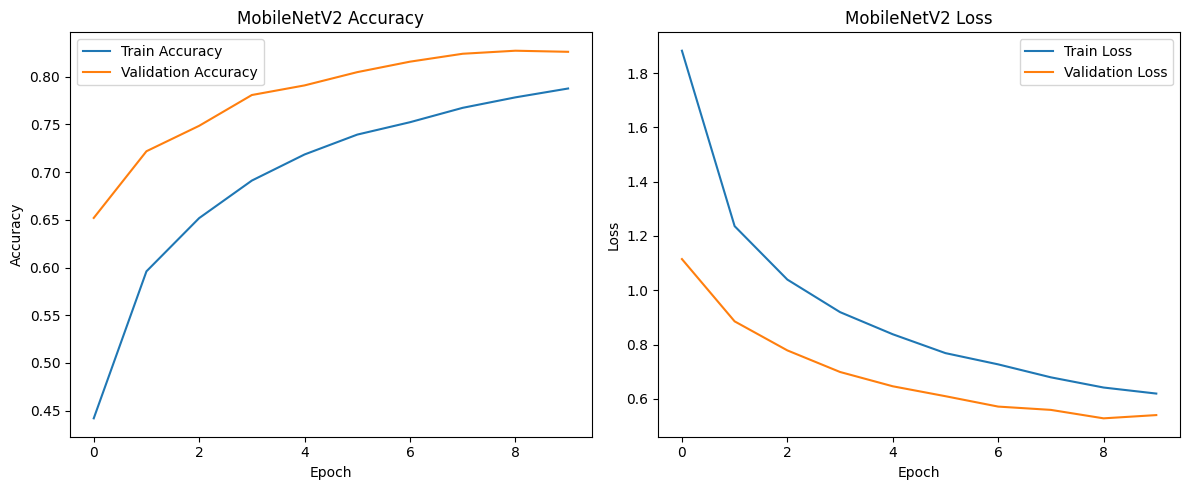

In [18]:
# MobileNetV2 learning curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_transfer.history["accuracy"], label="Train Accuracy")
plt.plot(history_transfer.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history["loss"], label="Train Loss")
plt.plot(history_transfer.history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

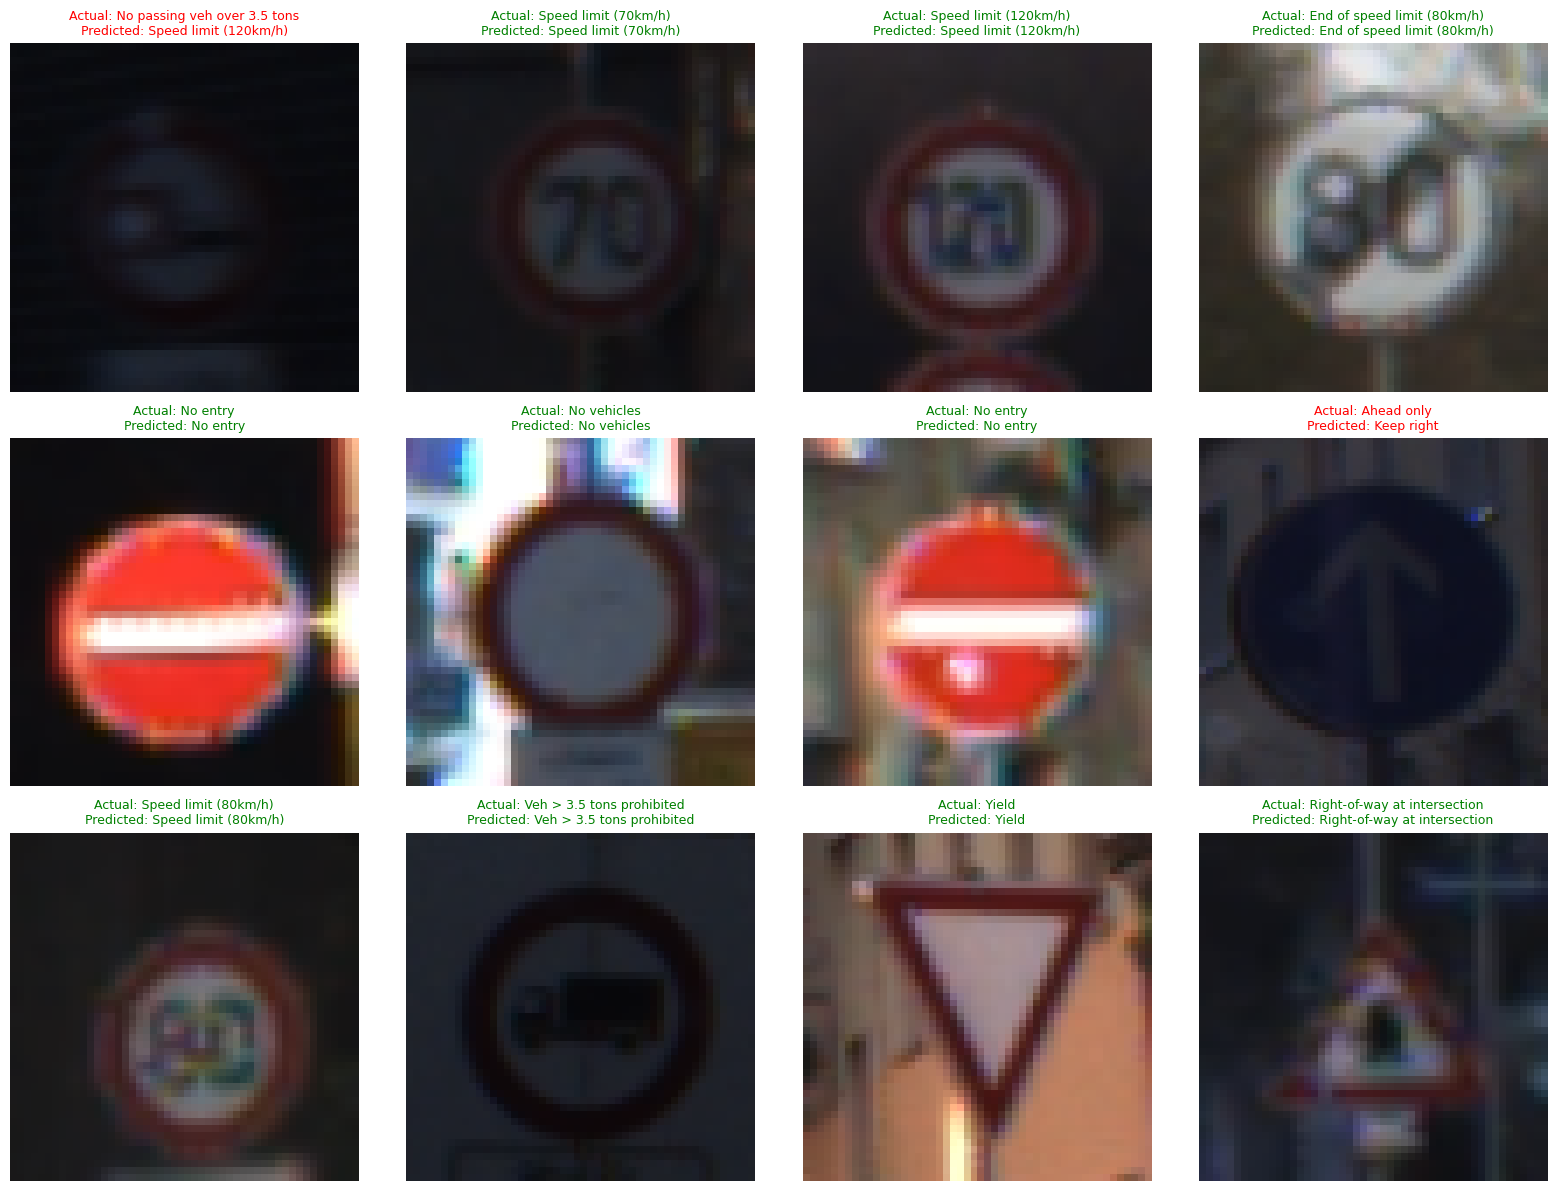

In [19]:
# MobileNetV2 predictions
y_true_transfer = []
y_pred_transfer = []

for images, labels in test_ds:
    predictions = transfer_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true_transfer.extend(labels.numpy())
    y_pred_transfer.extend(predicted_classes)

y_true_transfer = np.array(y_true_transfer)
y_pred_transfer = np.array(y_pred_transfer)

# Prediction visualisation for MobileNetV2
fig, ax = plt.subplots(3, 4)
fig.set_size_inches(16, 12)

for i in range(3):
    for j in range(4):
        idx = np.random.randint(0, len(X_test))

        actual = int(y_true_transfer[idx])
        predicted = int(y_pred_transfer[idx])

        ax[i, j].imshow(X_test[idx])

        color = "green" if actual == predicted else "red"

        ax[i, j].set_title(
            "Actual: " + classes[actual] +
            "\nPredicted: " + classes[predicted],
            color=color,
            fontsize=9
        )
        ax[i, j].axis("off")

plt.tight_layout()
plt.show()